In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(
    filepath_or_buffer='data/Cust_Segmentation.csv'
)

df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [3]:
df.drop(
    columns=['Customer Id', 'Address', 'Defaulted'],
    axis=1,
    inplace=True
)

df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,6.3
1,47,1,26,100,4.582,8.218,12.8
2,33,2,10,57,6.111,5.802,20.9
3,29,2,4,19,0.681,0.516,6.3
4,47,1,31,253,9.308,8.908,7.2


In [4]:
df.shape

(850, 7)

In [5]:
df.dtypes.to_frame(name='dtype')

,dtype
Age,int64
Edu,int64
Years Employed,int64
Income,int64
Card Debt,float64
Other Debt,float64
DebtIncomeRatio,float64


In [6]:
df.isnull().sum()

Age                0
Edu                0
Years Employed     0
Income             0
Card Debt          0
Other Debt         0
DebtIncomeRatio    0
dtype: int64

In [7]:
df.columns

Index(['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt',
       'DebtIncomeRatio'],
      dtype='object')

In [8]:
features = ['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt', 'DebtIncomeRatio']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.442507


1 || 0.0001
Initialization complete
Iteration 0, inertia 7240.8304726428505.
Iteration 1, inertia 5950.0.
Converged at iteration 1: strict convergence.
1 || 0.0001
Initialization complete
Iteration 0, inertia 5747.630220188782.
Iteration 1, inertia 4753.886841590351.
Iteration 2, inertia 4536.213280967918.
Iteration 3, inertia 4442.9909915503795.
Iteration 4, inertia 4397.198070703111.
Iteration 5, inertia 4373.006928431194.
Iteration 6, inertia 4361.195356785196.
Iteration 7, inertia 4355.549662943547.
Iteration 8, inertia 4352.336600803204.
Iteration 9, inertia 4350.10513030179.
Iteration 10, inertia 4348.563608728024.
Iteration 11, inertia 4346.9188574329855.
Iteration 12, inertia 4345.449326001167.
Iteration 13, inertia 4344.708371539533.
Iteration 14, inertia 4344.43732175324.
Iteration 15, inertia 4344.270071321562.
Iteration 16, inertia 4344.1364794705505.
Converged at iteration 16: strict convergence.
1 || 0.0001
Initialization complete
Iteration 0, inertia 4590.660330974245.
I

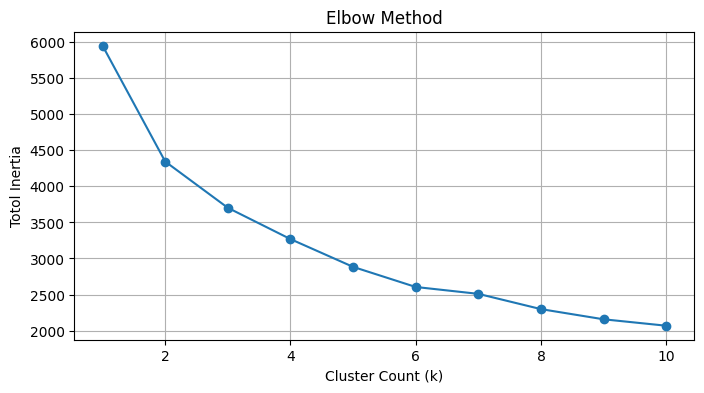

In [9]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42,
        verbose=1
    )

    print(f'{km.verbose} || {km.tol}')
    km.fit(X_scaled)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Totol Inertia')
plt.grid(True)
plt.show()

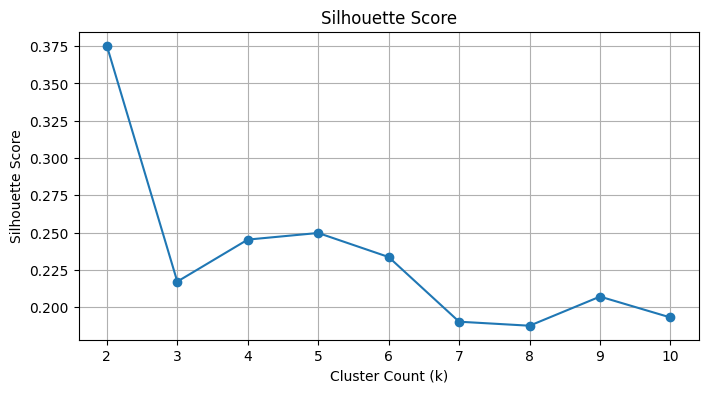

In [14]:
silhouette_scores = []

for k in range(2, 11):
    kmeans =  KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42,
    )

    kmeans.fit(X_scaled)

    labels = kmeans.labels_

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [15]:
silhouette_scores

[0.37524350822454117,
 0.2172394086659741,
 0.2453672982285242,
 0.24980591694366872,
 0.23369158902743958,
 0.1903698416141434,
 0.18767586572891834,
 0.20718651585558026,
 0.19320076361829208]

In [16]:
kmeans_final = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    random_state=42,
)

kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.labels_

df.head(20)

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,Cluster
0,41,2,6,19,0.124,1.073,6.3,1
1,47,1,26,100,4.582,8.218,12.8,2
2,33,2,10,57,6.111,5.802,20.9,2
3,29,2,4,19,0.681,0.516,6.3,1
4,47,1,31,253,9.308,8.908,7.2,3
5,40,1,23,81,0.998,7.831,10.9,0
6,38,2,4,56,0.442,0.454,1.6,1
7,42,3,0,64,0.279,3.945,6.6,1
8,26,1,5,18,0.575,2.215,15.5,1
9,47,3,23,115,0.653,3.947,4.0,0


In [17]:
cluster_profile = df.groupby('Cluster').mean().round(2)

cluster_profile.T

Cluster,0,1,2,3
Age,41.91,30.21,38.17,47.06
Edu,1.59,1.67,1.96,2.00
Years Employed,14.62,4.44,10.66,22.81
Income,65.12,28.07,58.81,204.25
Card Debt,1.28,0.75,3.41,10.92
Other Debt,2.48,1.60,6.84,15.81
DebtIncomeRatio,6.27,8.68,19.11,16.34


In [21]:
df.groupby('Cluster').count()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio,PCA1,PCA2
Cluster,,,,,,,,,
0,218,218,218,218,218,218,218,218,218
1,456,456,456,456,456,456,456,456,456
2,160,160,160,160,160,160,160,160,160
3,16,16,16,16,16,16,16,16,16


In [22]:
df['Cluster']

0      1
1      2
2      2
3      1
4      3
      ..
845    1
846    1
847    2
848    1
849    0
Name: Cluster, Length: 850, dtype: int32

c:\Users\pc\Desktop\machine_learning\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


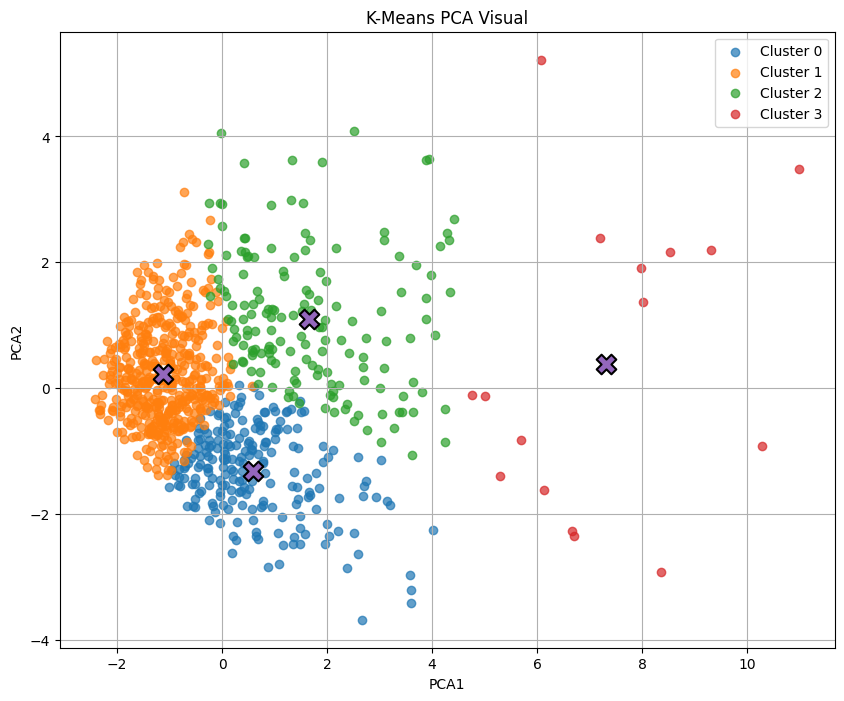

In [28]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

centers_pca_2d = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 8))

for c in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == c]
    plt.scatter(
        subset['PCA1'], 
        subset['PCA2'], 
        alpha=0.7,
        label=f'Cluster {c}'
    )

plt.scatter(
    centers_pca_2d[:, 0],
    centers_pca_2d[:, 1],
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.5
)

plt.title('K-Means PCA Visual')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid()
plt.legend()
plt.show()

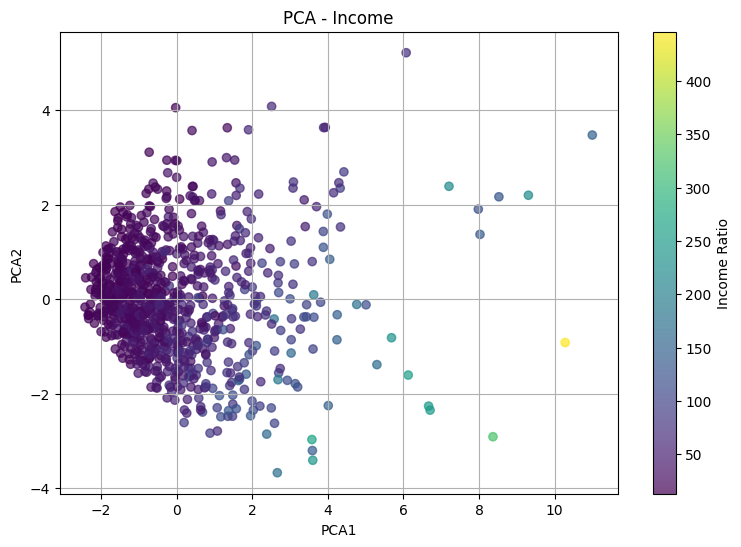

In [29]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df['PCA1'], 
    df['PCA2'], 
    alpha=0.7,
    c=df['Income']
)

cbar = plt.colorbar(scatter)
cbar.set_label('Income Ratio')

plt.title('PCA - Income')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid()
plt.show()


c:\Users\pc\Desktop\machine_learning\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


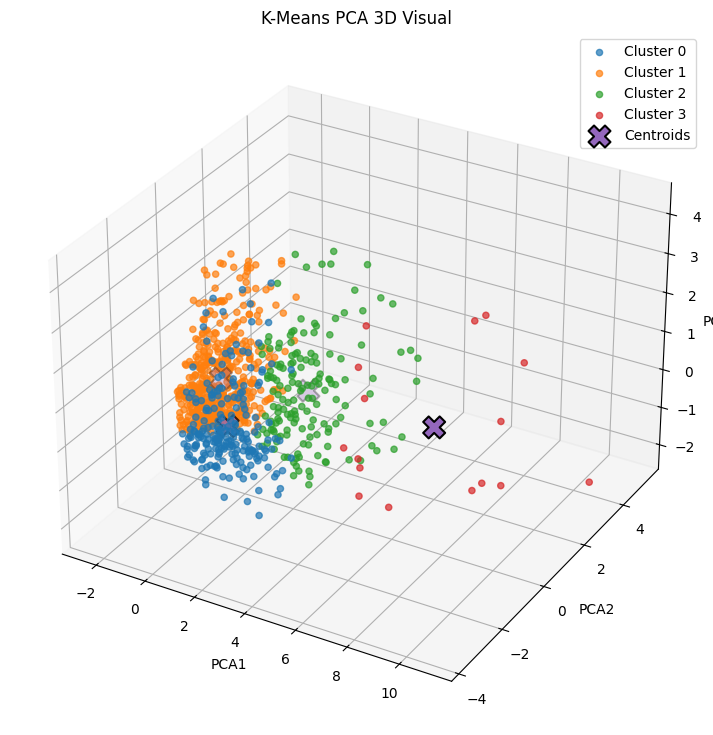

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # bazı ortamlarda gerekebilir

# PCA'yı 3 bileşene çıkar
pca = PCA(n_components=3)

# Veriyi 3 boyuta indir
pca_result = pca.fit_transform(X_scaled)

# DataFrame'e ekle
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]
df['PCA3'] = pca_result[:, 2]

# KMeans cluster merkezlerini de aynı PCA uzayına dönüştür
centers_pca_3d = pca.transform(kmeans_final.cluster_centers_)

# 3D figure
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Her cluster'ı ayrı çiz
for c in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == c]
    ax.scatter(
        subset['PCA1'],
        subset['PCA2'],
        subset['PCA3'],
        alpha=0.7,
        label=f'Cluster {c}'
    )

# Cluster merkezlerini çiz
ax.scatter(
    centers_pca_3d[:, 0],
    centers_pca_3d[:, 1],
    centers_pca_3d[:, 2],
    s=250,
    marker='X',
    edgecolors='black',
    linewidths=1.5,
    label='Centroids'
)

ax.set_title('K-Means PCA 3D Visual')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.legend()
plt.show()

In [ ]:
def predict_new_customer(data_dict:  dict) -> np.int32:
    
    input_df = pd.DataFrame(
        data=[data_dict],
        columns=features
    )

    input_scaled = scaler.transform(input_df)

    cluster_label = kmeans_final.predict(input_scaled)[0]
    
    return cluster_label

In [36]:
new_customer = {
    'Age': 45,
    'Edu': 1,
    'Years Employed': 14,
    'Income':  65,
    'Card Debt': 4.2,
    'Other Debt': 3.4,
    'DebtIncomeRatio': 19.01
}

predict_new_customer(data_dict=new_customer)

c:\Users\pc\Desktop\machine_learning\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


np.int32(2)